In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# 데이터 선정
dataset = pd.read_csv('선형회귀_성적.csv')
# print(dataset)

In [3]:
# 독립변수, 종속 변수 분리
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# print(X)
# print(y)

In [4]:
# 훈련,테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
# 학습
# max_iter : 훈련 세트 반복 횟수. Epoch 횟수
# eta0 : 학습률 
# verbose : epoch를 할 때마다 결과를 출력
# random_state : 데이터를 랜덤하게 선택할 때 사용될 기준
sgdr = SGDRegressor(max_iter=1000, eta0=1e-4)
sgdr.fit(X_train, y_train)

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
# 예측
y_predic = sgdr.predict(X_test)

# print(f'변수 값 : {X_test.squeeze().values}')
# print(f'예측 값 : {y_predic}')
# print(f'실제 값 : {y_test.values}')

In [7]:
# 성능을 확인
print(f'SGD 성능 : {sgdr.score(X_test, y_test)}')
print(f'LR  성능 : {lr.score(X_test, y_test)}')

SGD 성능 : 0.8429251929442513
LR  성능 : 0.8405294678919073


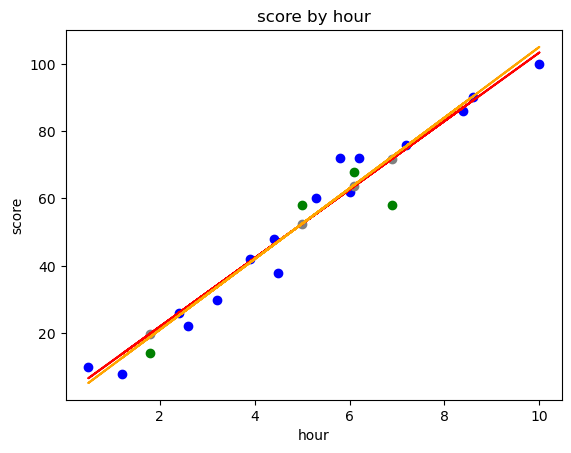

In [8]:
# 그래프로 확인
plt.scatter(X_train, y_train, color='blue') # 훈련 데이터를 점으로 출력
plt.plot(X_train, sgdr.predict(X_train), color='red') # SGD학습을 통해 나온 직선
plt.plot(X_train, lr.predict(X_train), color='orange') # LR학습을 통해 나온 직선
plt.scatter(X_test, sgdr.predict(X_test), color='gray') # 테스트 데이터의 예측 데이터
plt.scatter(X_test, y_test, color='green') # 테스트 데이터의 실제 데이터
plt.title('score by hour') # 그래프 제목
plt.xlabel('hour')# x축 => 독립변수
plt.ylabel('score')# y축 => 종속변수
plt.show() # 그래프 출력

In [9]:
model2 = LinearRegression() # 비교용